# TutorPulse Exploratory Data Analysis

## Stage 5: leakage-safe data preparation

This notebook examines TutorPulse's reproducible synthetic modelling dataset.

The working question is:

> Using only a learner's information available before a future assessment, can TutorPulse predict whether their next topic result will fall below the 60% support threshold?

This notebook performs data-quality checks and exploratory analysis. It does not train or select a predictive model.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve()

while (
    not (project_root / "data" / "prepared").exists()
    and project_root != project_root.parent
):
    project_root = project_root.parent

prepared_directory = project_root / "data" / "prepared"

if not prepared_directory.exists():
    raise FileNotFoundError(
        "Could not find data/prepared. Run the synthetic-data "
        "and modelling-dataset commands first."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from analysis.modelling_dataset import (
    MODEL_FEATURE_COLUMNS,
    TARGET_COLUMN,
)


dataset = pd.read_csv(
    prepared_directory / "modelling_dataset.csv",
    parse_dates=["assessment_date"],
)

split_frames = {}

for split_name in ("train", "validation", "test"):
    split_frames[split_name] = pd.read_csv(
        prepared_directory / f"{split_name}.csv",
        parse_dates=["assessment_date"],
    )

split_labels = pd.concat(
    [
        pd.DataFrame(
            {
                "result_id": split_frame["result_id"],
                "split": split_name,
            }
        )
        for split_name, split_frame in split_frames.items()
    ],
    ignore_index=True,
)

dataset = dataset.merge(
    split_labels,
    on="result_id",
    how="left",
    validate="one_to_one",
)

dataset["split"] = pd.Categorical(
    dataset["split"],
    categories=["train", "validation", "test"],
    ordered=True,
)

assert dataset["split"].notna().all()

print("Prepared directory:", prepared_directory)
print("Dataset loaded successfully.")

Prepared directory: C:\Users\omaru\Documents\tutorpulse\data\prepared
Dataset loaded successfully.


In [2]:
print(f"Rows: {len(dataset):,}")
print(f"Columns: {len(dataset.columns)}")
print(
    "Assessment dates:",
    dataset["assessment_date"].min().date(),
    "to",
    dataset["assessment_date"].max().date(),
)
print(
    "Unique learners:",
    dataset["learner_id"].nunique(),
)
print(
    "Unique assessments:",
    dataset["assessment_id"].nunique(),
)
print(
    "Unique topics:",
    dataset["topic_name"].nunique(),
)

display(dataset.head())

Rows: 10,056
Columns: 26
Assessment dates: 2025-01-29 to 2025-12-03
Unique learners: 120
Unique assessments: 23
Unique topics: 4


,result_id,learner_id,assessment_id,assessment_date,topic_id,topic_name,maximum_score,prior_assessment_count,prior_result_count,prior_average_percentage,...,prior_same_topic_count,prior_same_topic_average_percentage,prior_same_topic_latest_percentage,prior_same_topic_support_count,prior_intervention_count,prior_same_topic_intervention_count,prior_completed_intervention_count,result_percentage,needs_support,split
0,481,1,2,2025-01-29,1,Algebra,25.0,1,4,58.5375,...,1,58.10,58.10,1,2,0,1,73.24,0,train
1,482,1,2,2025-01-29,2,Fractions,25.0,1,4,58.5375,...,1,60.95,60.95,0,2,0,1,44.68,1,train
2,483,1,2,2025-01-29,3,Geometry,25.0,1,4,58.5375,...,1,55.45,55.45,1,2,1,1,57.56,1,train
3,484,1,2,2025-01-29,4,Statistics,25.0,1,4,58.5375,...,1,59.65,59.65,1,2,0,1,63.84,0,train
4,485,2,2,2025-01-29,1,Algebra,25.0,1,4,53.2375,...,1,64.50,64.50,0,1,0,1,50.96,1,train


In [3]:
duplicate_target_rows = dataset.duplicated(
    subset=[
        "learner_id",
        "assessment_id",
        "topic_id",
    ]
).sum()

missing_feature_values = (
    dataset[MODEL_FEATURE_COLUMNS]
    .isna()
    .sum()
    .sum()
)

quality_summary = pd.Series(
    {
        "rows": len(dataset),
        "duplicate_target_rows": duplicate_target_rows,
        "missing_feature_values": missing_feature_values,
        "invalid_result_percentages": (
            dataset["result_percentage"]
            .lt(0)
            .sum()
            + dataset["result_percentage"]
            .gt(100)
            .sum()
        ),
        "invalid_target_values": (
            ~dataset[TARGET_COLUMN].isin([0, 1])
        ).sum(),
        "rows_without_prior_results": (
            dataset["prior_result_count"].eq(0)
        ).sum(),
    },
    name="value",
)

display(quality_summary.to_frame())

assert duplicate_target_rows == 0
assert missing_feature_values == 0
assert dataset["result_percentage"].between(
    0,
    100,
).all()
assert dataset[TARGET_COLUMN].isin([0, 1]).all()
assert dataset["prior_result_count"].gt(0).all()

,value
rows,10056
duplicate_target_rows,0
missing_feature_values,0
invalid_result_percentages,0
invalid_target_values,0
rows_without_prior_results,0


In [4]:
summary_columns = [
    "result_percentage",
    "prior_assessment_count",
    "prior_result_count",
    "prior_average_percentage",
    "prior_support_rate",
    "prior_same_topic_average_percentage",
    "prior_intervention_count",
]

display(
    dataset[summary_columns]
    .describe()
    .round(2)
)

,result_percentage,prior_assessment_count,prior_result_count,prior_average_percentage,prior_support_rate,prior_same_topic_average_percentage,prior_intervention_count
count,10056.00,10056.00,10056.00,10056.00,10056.00,10056.00,10056.00
mean,65.42,11.02,44.08,63.44,0.39,63.44,4.93
std,12.57,6.12,24.47,9.44,0.32,10.39,5.51
min,16.70,1.00,4.00,36.62,0.00,23.75,0.00
25%,56.95,6.00,24.00,57.08,0.09,56.18,1.00
50%,65.48,11.00,44.00,63.33,0.33,63.68,3.00
75%,73.96,16.00,64.00,70.51,0.65,70.67,8.00
max,98.00,23.00,92.00,90.52,1.00,98.00,29.00


,rows,percentage
needs_support,,
0,6706,66.69
1,3350,33.31


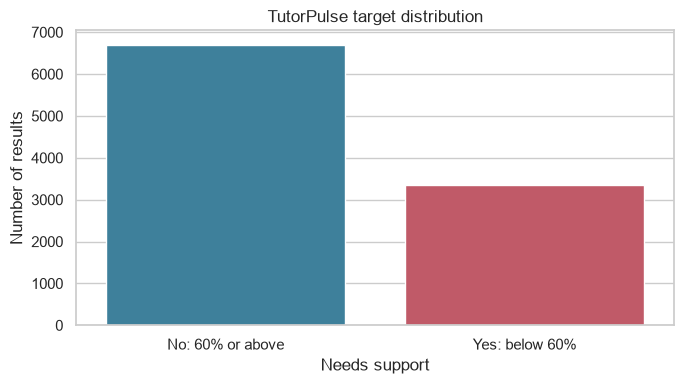

In [5]:
target_summary = (
    dataset[TARGET_COLUMN]
    .value_counts()
    .rename_axis(TARGET_COLUMN)
    .to_frame("rows")
)

target_summary["percentage"] = (
    target_summary["rows"]
    / len(dataset)
    * 100
)

display(target_summary.round(2))

plt.figure(figsize=(7, 4))

axis = sns.countplot(
    data=dataset,
    x=TARGET_COLUMN,
    hue=TARGET_COLUMN,
    palette={
        0: "#2E86AB",
        1: "#D1495B",
    },
    legend=False,
)

axis.set_title("TutorPulse target distribution")
axis.set_xlabel("Needs support")
axis.set_ylabel("Number of results")
axis.set_xticks([0, 1])
axis.set_xticklabels(
    [
        "No: 60% or above",
        "Yes: below 60%",
    ]
)

plt.tight_layout()
plt.show()

,rows,average_result,support_rate,support_rate_percentage
topic_name,,,,
Fractions,2514,60.69,0.47,47.33
Algebra,2514,63.79,0.38,37.51
Geometry,2514,67.65,0.27,26.97
Statistics,2514,69.53,0.21,21.44


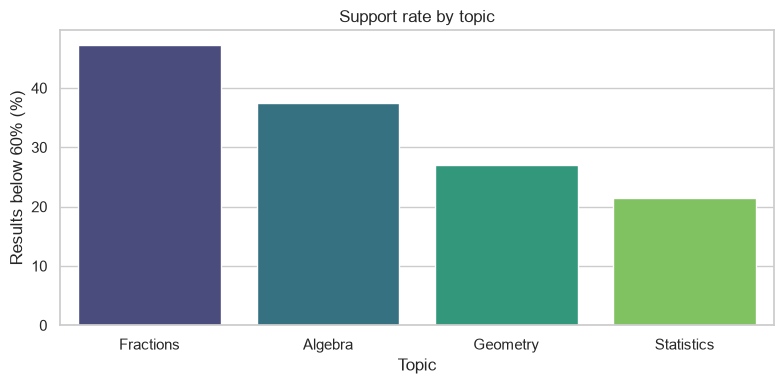

In [6]:
topic_summary = (
    dataset.groupby(
        "topic_name",
        observed=True,
    )
    .agg(
        rows=("result_id", "size"),
        average_result=("result_percentage", "mean"),
        support_rate=(TARGET_COLUMN, "mean"),
    )
    .sort_values(
        "support_rate",
        ascending=False,
    )
)

topic_summary["support_rate_percentage"] = (
    topic_summary["support_rate"]
    * 100
)

display(topic_summary.round(2))

plt.figure(figsize=(8, 4))

axis = sns.barplot(
    data=topic_summary.reset_index(),
    x="topic_name",
    y="support_rate_percentage",
    hue="topic_name",
    palette="viridis",
    legend=False,
)

axis.set_title("Support rate by topic")
axis.set_xlabel("Topic")
axis.set_ylabel("Results below 60% (%)")

plt.tight_layout()
plt.show()

C:\Users\omaru\AppData\Local\Temp\ipykernel_27768\2573638516.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(split_summary.round(3))


,rows,first_date,last_date,average_result,support_rate,support_rate_percentage
split,,,,,,
train,5668,2025-01-29,2025-07-16,63.998,0.372,37.244
validation,2168,2025-07-30,2025-09-24,66.428,0.300,30.028
test,2220,2025-10-08,2025-12-03,68.044,0.265,26.486


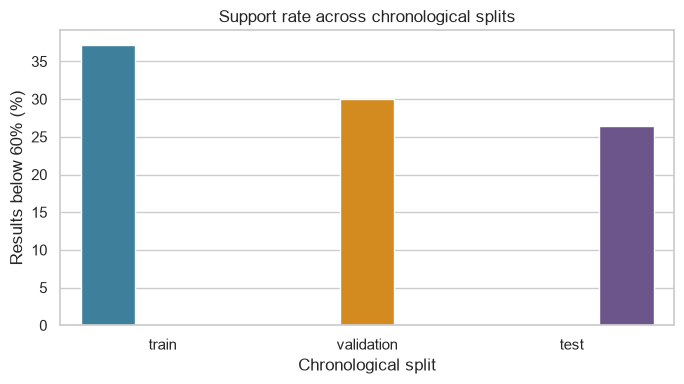

In [7]:
split_summary = (
    dataset.groupby(
        "split",
        observed=False,
    )
    .agg(
        rows=("result_id", "size"),
        first_date=("assessment_date", "min"),
        last_date=("assessment_date", "max"),
        average_result=("result_percentage", "mean"),
        support_rate=(TARGET_COLUMN, "mean"),
    )
)

split_summary["support_rate_percentage"] = (
    split_summary["support_rate"]
    * 100
)

display(split_summary.round(3))

plt.figure(figsize=(7, 4))

axis = sns.barplot(
    data=split_summary.reset_index(),
    x="split",
    y="support_rate_percentage",
    hue="split",
    palette={
        "train": "#2E86AB",
        "validation": "#F18F01",
        "test": "#6A4C93",
    },
    legend=False,
)

axis.set_title("Support rate across chronological splits")
axis.set_xlabel("Chronological split")
axis.set_ylabel("Results below 60% (%)")

plt.tight_layout()
plt.show()

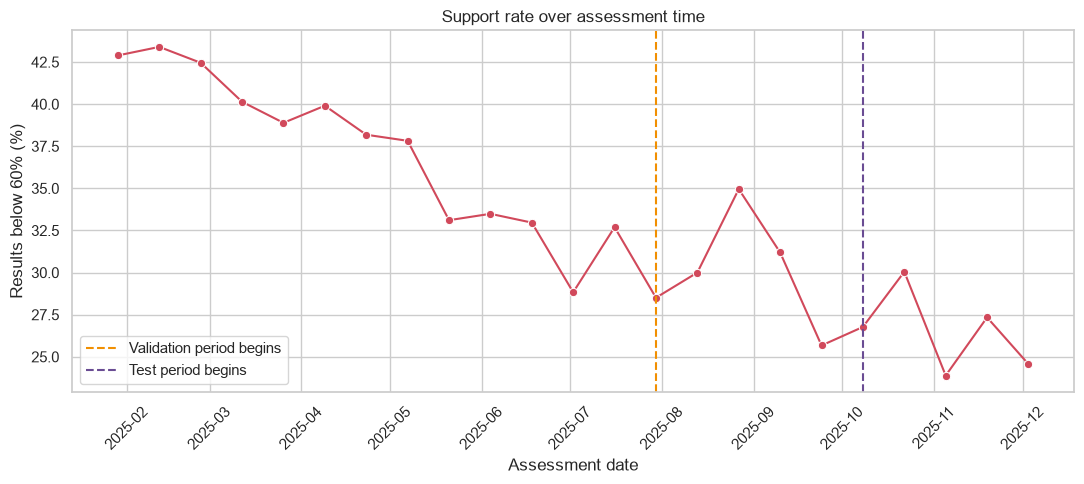

In [8]:
temporal_summary = (
    dataset.groupby(
        "assessment_date",
        as_index=False,
    )
    .agg(
        rows=("result_id", "size"),
        average_result=("result_percentage", "mean"),
        support_rate=(TARGET_COLUMN, "mean"),
    )
)

temporal_summary["support_rate_percentage"] = (
    temporal_summary["support_rate"]
    * 100
)

validation_start = split_frames[
    "validation"
]["assessment_date"].min()

test_start = split_frames[
    "test"
]["assessment_date"].min()

plt.figure(figsize=(11, 5))

axis = sns.lineplot(
    data=temporal_summary,
    x="assessment_date",
    y="support_rate_percentage",
    marker="o",
    color="#D1495B",
)

axis.axvline(
    validation_start,
    color="#F18F01",
    linestyle="--",
    label="Validation period begins",
)

axis.axvline(
    test_start,
    color="#6A4C93",
    linestyle="--",
    label="Test period begins",
)

axis.set_title("Support rate over assessment time")
axis.set_xlabel("Assessment date")
axis.set_ylabel("Results below 60% (%)")
axis.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

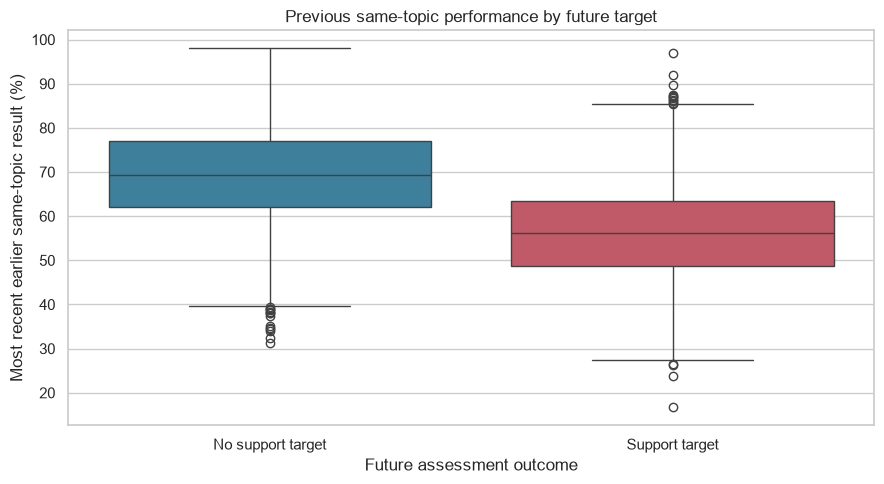

In [9]:
plot_data = dataset.copy()

plot_data["target_label"] = plot_data[
    TARGET_COLUMN
].map(
    {
        0: "No support target",
        1: "Support target",
    }
)

plt.figure(figsize=(9, 5))

axis = sns.boxplot(
    data=plot_data,
    x="target_label",
    y="prior_same_topic_latest_percentage",
    hue="target_label",
    palette={
        "No support target": "#2E86AB",
        "Support target": "#D1495B",
    },
    legend=False,
)

axis.set_title(
    "Previous same-topic performance by future target"
)
axis.set_xlabel("Future assessment outcome")
axis.set_ylabel(
    "Most recent earlier same-topic result (%)"
)

plt.tight_layout()
plt.show()

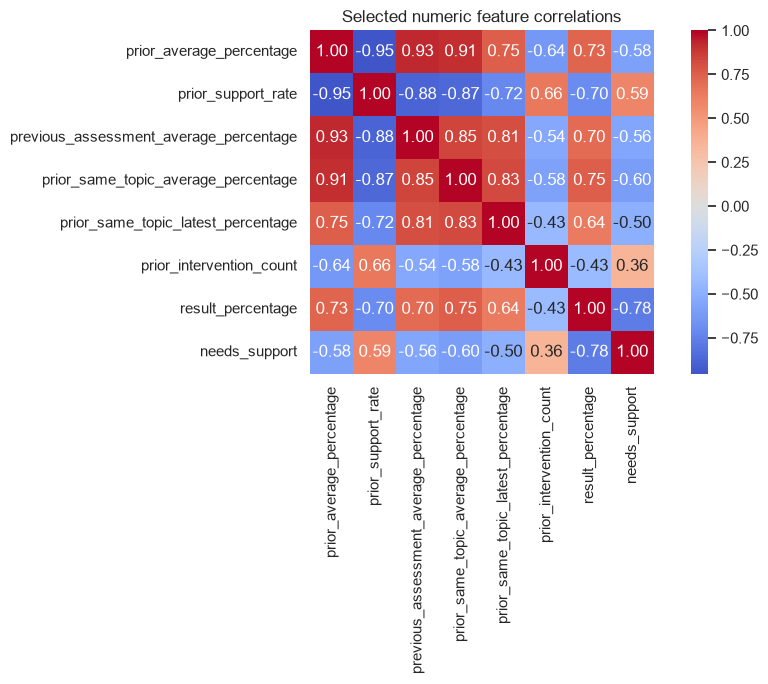

In [10]:
correlation_columns = [
    "prior_average_percentage",
    "prior_support_rate",
    "previous_assessment_average_percentage",
    "prior_same_topic_average_percentage",
    "prior_same_topic_latest_percentage",
    "prior_intervention_count",
    "result_percentage",
    TARGET_COLUMN,
]

correlations = (
    dataset[correlation_columns]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Selected numeric feature correlations")
plt.tight_layout()
plt.show()

In [11]:
overall_support_rate = (
    dataset[TARGET_COLUMN].mean()
)

highest_support_topic = (
    topic_summary["support_rate"].idxmax()
)

highest_topic_support_rate = (
    topic_summary.loc[
        highest_support_topic,
        "support_rate",
    ]
)

lowest_support_topic = (
    topic_summary["support_rate"].idxmin()
)

lowest_topic_support_rate = (
    topic_summary.loc[
        lowest_support_topic,
        "support_rate",
    ]
)

print(
    f"Overall support rate: "
    f"{overall_support_rate:.1%}"
)

print(
    f"Highest topic support rate: "
    f"{highest_support_topic} "
    f"({highest_topic_support_rate:.1%})"
)

print(
    f"Lowest topic support rate: "
    f"{lowest_support_topic} "
    f"({lowest_topic_support_rate:.1%})"
)

for split_name in (
    "train",
    "validation",
    "test",
):
    rate = split_summary.loc[
        split_name,
        "support_rate",
    ]

    print(
        f"{split_name.title()} support rate: "
        f"{rate:.1%}"
    )

Overall support rate: 33.3%
Highest topic support rate: Fractions (47.3%)
Lowest topic support rate: Statistics (21.4%)
Train support rate: 37.2%
Validation support rate: 30.0%
Test support rate: 26.5%


## Interpretation and limitations

The prepared dataset contains both support and non-support outcomes, so the future classification task is viable.

The support rate changes across chronological periods. This is expected because the generator gives learners different rates of progress. It also means that Stage 6 must evaluate models on later data rather than relying on a random split.

Earlier performance appears related to future outcomes. This makes historical assessment aggregates reasonable candidate features, although correlation alone does not establish causation.

Topic-level differences are deliberately present in the synthetic generator. They allow the project to test categorical features, but they must not be presented as evidence about real learners or real curriculum difficulty.

Intervention counts describe support that existed before the target assessment. They do not measure the causal effectiveness of an intervention. Learners with more interventions may simply have had greater prior support needs.

The test period has only been inspected to document data quality and distribution shift. It will not be used for feature selection, model selection or threshold tuning during Stage 6.

All learners and outcomes are fictional. Findings from this notebook do not demonstrate real educational effectiveness.